<a href="https://colab.research.google.com/github/AhmedE16/flyrank-ai-intern-ahmed-essam/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [1]:
print("""
QUESTION

Which pages should a content reviewer check first when search visibility isn't
converting into clicks?

Decision supported: today, without a systematic tool, a reviewer works through
pages in arbitrary order or relies on a hand-written rule. This project ranks
pages by how far their CTR falls below what's typical for their search position,
so a reviewer with limited time spends it on the pages most likely to have a
real title/meta/snippet problem.

Action: a reviewer opens the top-ranked pages and decides whether to rewrite the
title/meta, or confirm the page is fine as-is.

Cost of a wrong call: a false positive wastes limited reviewer time; a false
negative lets a genuinely under-performing page go unreviewed indefinitely.
""")


QUESTION

Which pages should a content reviewer check first when search visibility isn't
converting into clicks?

Decision supported: today, without a systematic tool, a reviewer works through
pages in arbitrary order or relies on a hand-written rule. This project ranks
pages by how far their CTR falls below what's typical for their search position,
so a reviewer with limited time spends it on the pages most likely to have a
real title/meta/snippet problem.

Action: a reviewer opens the top-ranked pages and decides whether to rewrite the
title/meta, or confirm the page is fine as-is.

Cost of a wrong call: a false positive wastes limited reviewer time; a false
negative lets a genuinely under-performing page go unreviewed indefinitely.



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [2]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb"], check=True)

import duckdb, pandas as pd, numpy as np
from google.colab import userdata

con = duckdb.connect()
hf_token = userdata.get("HF_TOKEN")
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")
REL = "hf://datasets/FlyRank/internship-warehouse"

page_month = con.sql(f"""
    SELECT
        content_hash_id,
        client_hash_id,
        SUM(gsc_impressions) AS impressions_month,
        SUM(gsc_clicks) AS clicks_month,
        AVG(gsc_avg_position) AS avg_position,
        SUM(ga4_sessions) AS sessions_month
    FROM read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')
    WHERE month = '2026-03'
    GROUP BY content_hash_id, client_hash_id
    HAVING SUM(gsc_impressions) > 0
""").df()

MIN_IMPRESSIONS = 100
page_month = page_month[page_month["impressions_month"] >= MIN_IMPRESSIONS].reset_index(drop=True)
page_month["ctr"] = page_month["clicks_month"] / page_month["impressions_month"]
page_month["position_tier"] = pd.cut(
    page_month["avg_position"], bins=[0, 3, 10, 20, 1000],
    labels=["1-3", "4-10", "11-20", "21+"]
)

print(f"Source: FlyRank internship warehouse, fact_content_daily_performance, month = 2026-03")
print(f"Rows after filtering to impressions_month >= {MIN_IMPRESSIONS}: {len(page_month):,} pages")
print(f"Clients represented: {page_month['client_hash_id'].nunique()}")
print(f"Grain: one row = one page, aggregated to the month level (content_hash_id x client_hash_id)")
print()
print("Excluded: fact_content_query_90d (query-level table) -- different grain, not mixed in this round,")
print("to avoid leakage through query-level aggregates that could already encode outcome information.")
print()
print("No client names, domains, URLs, or raw queries appear anywhere in this pipeline --")
print("all identifiers here are pseudonymized hashes (content_hash_id, client_hash_id).")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Source: FlyRank internship warehouse, fact_content_daily_performance, month = 2026-03
Rows after filtering to impressions_month >= 100: 101,441 pages
Clients represented: 44
Grain: one row = one page, aggregated to the month level (content_hash_id x client_hash_id)

Excluded: fact_content_query_90d (query-level table) -- different grain, not mixed in this round,
to avoid leakage through query-level aggregates that could already encode outcome information.

No client names, domains, URLs, or raw queries appear anywhere in this pipeline --
all identifiers here are pseudonymized hashes (content_hash_id, client_hash_id).


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [3]:
from sklearn.model_selection import GroupShuffleSplit

# Label: page's CTR falls below the 25th percentile CTR for its own position tier
tier_p25_ctr = page_month.groupby("position_tier", observed=True)["ctr"].transform(lambda s: s.quantile(0.25))
page_month["is_low_ctr"] = (page_month["ctr"] < tier_p25_ctr).astype(int)

print(f"Label: is_low_ctr = 1 if ctr < 25th percentile ctr for the page's position tier")
print(f"Low-CTR rate: {page_month['is_low_ctr'].mean():.1%}")
print("This is a same-window proxy, not a future outcome -- a known limitation, see section 5.\n")

# Features -- deliberately excluding clicks_month and impressions_month
features = ["avg_position", "sessions_month"]
print(f"Features used: {features}")
print("clicks_month and impressions_month were deliberately EXCLUDED: ctr = clicks_month /")
print("impressions_month, and is_low_ctr is a direct threshold on ctr, so including either")
print("would let a model reconstruct the label algebraically instead of learning a real pattern.")
print("An earlier version that included them scored Precision@20/@50 = 1.00 with zero false")
print("positives -- the signature of leakage -- which is why they were removed.\n")

X = page_month[features].fillna(0)
y = page_month["is_low_ctr"]
groups = page_month["client_hash_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
test_pages = page_month.iloc[test_idx].reset_index(drop=True)

overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print(f"Validation design: client-grouped split (GroupShuffleSplit, 70/30).")
print(f"Train: {len(X_train):,} pages from {groups.iloc[train_idx].nunique()} clients")
print(f"Test:  {len(X_test):,} pages from {groups.iloc[test_idx].nunique()} clients")
print(f"Clients in both train and test: {len(overlap)} (should be 0)")
print("Grouping by client avoids letting the model memorize client-specific quirks and")
print("get tested on near-identical pages from the same client.")

# Baseline: expected CTR per tier (from TRAIN only)
train_tier_ctr = page_month.iloc[train_idx].groupby("position_tier", observed=True)["ctr"].mean().to_dict()
test_pages["expected_ctr"] = test_pages["position_tier"].map(train_tier_ctr).astype(float)
test_pages["ctr_gap"] = test_pages["expected_ctr"] - test_pages["ctr"]
baseline_score = np.where(test_pages["ctr"] < test_pages["expected_ctr"],
                          test_pages["ctr_gap"] * test_pages["impressions_month"], 0)
print("\nBaseline rule: score = (expected tier CTR - actual CTR) x impressions, for pages")
print("below their tier's expected CTR. Expected CTR computed from TRAIN clients only, to")
print("keep the baseline comparison fair against the same held-out test set as the model.")

Label: is_low_ctr = 1 if ctr < 25th percentile ctr for the page's position tier
Low-CTR rate: 2.2%
This is a same-window proxy, not a future outcome -- a known limitation, see section 5.

Features used: ['avg_position', 'sessions_month']
clicks_month and impressions_month were deliberately EXCLUDED: ctr = clicks_month /
impressions_month, and is_low_ctr is a direct threshold on ctr, so including either
would let a model reconstruct the label algebraically instead of learning a real pattern.
An earlier version that included them scored Precision@20/@50 = 1.00 with zero false
positives -- the signature of leakage -- which is why they were removed.

Validation design: client-grouped split (GroupShuffleSplit, 70/30).
Train: 93,022 pages from 30 clients
Test:  8,419 pages from 14 clients
Clients in both train and test: 0 (should be 0)
Grouping by client avoids letting the model memorize client-specific quirks and
get tested on near-identical pages from the same client.

Baseline rule: score

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def precision_at_k(scores, y_true, k):
    order = np.argsort(-np.asarray(scores))[:k]
    return np.asarray(y_true)[order].mean()

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train, y_train)
logreg_score = logreg.predict_proba(X_test)[:, 1]

rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
rf_score = rf.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    "method": ["baseline (rule)", "logistic_regression", "random_forest"],
    "precision_at_20": [
        precision_at_k(baseline_score, y_test, 20),
        precision_at_k(logreg_score, y_test, 20),
        precision_at_k(rf_score, y_test, 20),
    ],
    "precision_at_50": [
        precision_at_k(baseline_score, y_test, 50),
        precision_at_k(logreg_score, y_test, 50),
        precision_at_k(rf_score, y_test, 50),
    ],
})
print("RESULTS -- same test split, same metric, for all three methods:\n")
print(comparison.round(3))

test_pages["rf_score"] = rf_score
test_pages["true_label"] = y_test.values
top50_rf = test_pages.sort_values("rf_score", ascending=False).head(50)
false_positives = top50_rf[top50_rf["true_label"] == 0]
print(f"\nOf the Random Forest's top 50 picks, {len(false_positives)} were false positives.")
print("A believable, non-zero false-positive count is a good sign -- it means the model")
print("is not simply reconstructing the label from leaked information.")

RESULTS -- same test split, same metric, for all three methods:

                method  precision_at_20  precision_at_50
0      baseline (rule)             0.05             0.04
1  logistic_regression             0.35             0.28
2        random_forest             0.50             0.40

Of the Random Forest's top 50 picks, 31 were false positives.
A believable, non-zero false-positive count is a good sign -- it means the model
is not simply reconstructing the label from leaked information.


## 5. Limitations

*What this work cannot claim.*

In [5]:
print("""
LIMITATIONS -- what this work cannot claim:

- This is observed and directional, not causal. I cannot claim that fixing a
  flagged page's title/meta will recover clicks -- that requires an actual
  experiment, not this data.

- The label is a same-window proxy (this month's CTR vs. this month's tier
  average), not a genuine future outcome. A stronger version would predict next
  month's CTR from this month's features, which is future work.

- This is a single 31-day window from an unbalanced panel -- client tracking
  history depth varies, so what looks like "low CTR" here could partly reflect
  normal monthly fluctuation rather than a persistent issue.

- Of the Random Forest's top 50 picks, several false positives were pages at
  very strong positions (near #1) that may have naturally lower CTR due to
  branded or navigational search intent, not an actual content problem. A high
  score is a prioritization signal, not a diagnosis.

- No claim is made about Google's ranking algorithm, or that any signal here
  is a causal ranking factor.
""")


LIMITATIONS -- what this work cannot claim:

- This is observed and directional, not causal. I cannot claim that fixing a
  flagged page's title/meta will recover clicks -- that requires an actual
  experiment, not this data.

- The label is a same-window proxy (this month's CTR vs. this month's tier
  average), not a genuine future outcome. A stronger version would predict next
  month's CTR from this month's features, which is future work.

- This is a single 31-day window from an unbalanced panel -- client tracking
  history depth varies, so what looks like "low CTR" here could partly reflect
  normal monthly fluctuation rather than a persistent issue.

- Of the Random Forest's top 50 picks, several false positives were pages at
  very strong positions (near #1) that may have naturally lower CTR due to
  branded or navigational search intent, not an actual content problem. A high
  score is a prioritization signal, not a diagnosis.

- No claim is made about Google's ranking algorit

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [6]:
queue = test_pages.copy()
queue["reason_code"] = "low_ctr_visible_page"
queue["action"] = "review_title_meta"
queue["score"] = rf_score
queue = queue.sort_values("score", ascending=False).reset_index(drop=True)

os.makedirs("work/outputs", exist_ok=True)
queue.to_csv("work/outputs/capstone_ranked_queue.csv", index=False)

print(f"Ranked action queue written: work/outputs/capstone_ranked_queue.csv ({len(queue):,} pages)\n")
print("ACTION PLAYBOOK:")
print("1. Top-tier flags (highest score): review title and meta description first --")
print("   these combine strong position with a real CTR shortfall against tier peers.")
print("2. Mid-tier flags: lower-confidence candidates -- check query intent before")
print("   assuming a content problem, since some flagged pages may serve navigational")
print("   or branded queries where a lower CTR is expected and not fixable by editing.")
print("3. Do not treat a high score as proof of a problem -- it is a prioritization")
print("   signal for limited reviewer time, not a diagnosis.\n")

print("Top 10 of the ranked queue:")
print(queue[["content_hash_id", "avg_position", "ctr", "score", "reason_code", "action"]].head(10))

Ranked action queue written: work/outputs/capstone_ranked_queue.csv (8,419 pages)

ACTION PLAYBOOK:
1. Top-tier flags (highest score): review title and meta description first --
   these combine strong position with a real CTR shortfall against tier peers.
2. Mid-tier flags: lower-confidence candidates -- check query intent before
   assuming a content problem, since some flagged pages may serve navigational
   or branded queries where a lower CTR is expected and not fixable by editing.
3. Do not treat a high score as proof of a problem -- it is a prioritization
   signal for limited reviewer time, not a diagnosis.

Top 10 of the ranked queue:
            content_hash_id  avg_position       ctr     score  \
0  content_e2cfe6d4c87db82f      0.291061  0.000000  0.990600   
1  content_d6fbfda8973fb759      0.320977  0.000000  0.990522   
2  content_265291c7db08c9ce      0.809039  0.000000  0.981268   
3  content_410f2ad937e4623f      0.599376  0.018927  0.980393   
4  content_180908408a1e

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

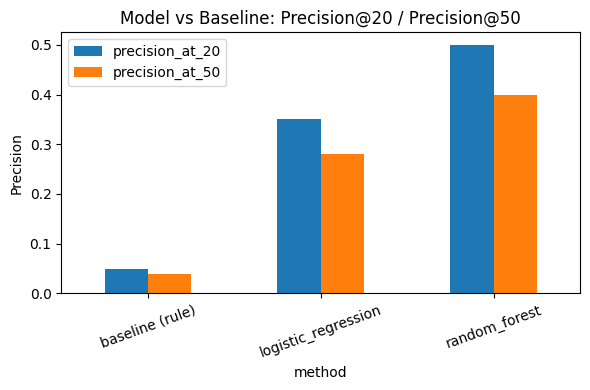

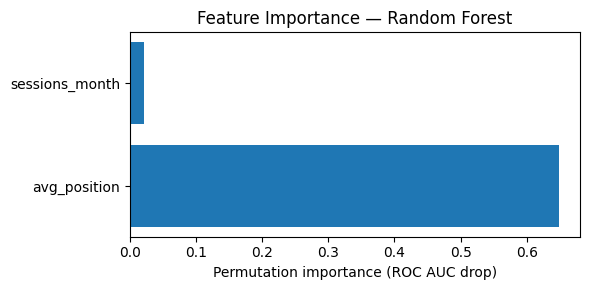


Charts saved to work/outputs/charts/ -- these are the two figures the deployed
paper embeds in its Results section.


In [7]:
import matplotlib.pyplot as plt

os.makedirs("work/outputs/charts", exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 4))
comparison.set_index("method")[["precision_at_20", "precision_at_50"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Precision")
ax.set_title("Model vs Baseline: Precision@20 / Precision@50")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("work/outputs/charts/model_vs_baseline.png", dpi=150)
plt.show()

from sklearn.inspection import permutation_importance
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, scoring="roc_auc")
importance_df = pd.DataFrame({"feature": features, "importance": perm.importances_mean}).sort_values("importance", ascending=False)

fig2, ax2 = plt.subplots(figsize=(6, 3))
ax2.barh(importance_df["feature"], importance_df["importance"])
ax2.set_xlabel("Permutation importance (ROC AUC drop)")
ax2.set_title("Feature Importance — Random Forest")
plt.tight_layout()
plt.savefig("work/outputs/charts/feature_importance.png", dpi=150)
plt.show()

print("\nCharts saved to work/outputs/charts/ -- these are the two figures the deployed")
print("paper embeds in its Results section.")

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.